# OCR Image Noise Augmentation

Adds realistic noise to OCR images for EN, MY, CN to create a harder dataset.

In [1]:
# 1) Imports and config
import os
import csv
import random
from pathlib import Path
from typing import Tuple

import numpy as np
from PIL import Image, ImageFilter, ImageEnhance
import cv2
from skimage.util import random_noise

random.seed(42)
np.random.seed(42)

BASE_DIR = Path.cwd()
SRC_DIR = BASE_DIR / 'ocr_images'
DEST_DIR = BASE_DIR / 'ocr_images_noisy'
LANGS = ['EN', 'MY', 'CN']
NUM_IMAGES_PER_LANG = 5000  # expected

DEST_DIR.mkdir(exist_ok=True)
for lang in LANGS:
    (DEST_DIR / lang).mkdir(parents=True, exist_ok=True)


In [2]:
# 2) Load image paths and labels

def load_labels(lang: str):
    labels_path = SRC_DIR / lang / 'labels.csv'
    items = []
    with labels_path.open('r', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            fname = row.get('filename') or row.get('file') or row.get('image')
            text = row.get('text', '')
            if fname:
                items.append((fname, text))
    return items

all_items = {lang: load_labels(lang) for lang in LANGS}
for lang in LANGS:
    print(f'{lang}: loaded {len(all_items[lang])} rows')

EN: loaded 5000 rows
MY: loaded 5000 rows
CN: loaded 5000 rows


In [6]:
# 3) Define noise functions

# Gaussian noise: mimics sensor noise; increase sigma for heavier grain.
def add_gaussian_noise(img: Image.Image, sigma: float = 10.0) -> Image.Image:
    arr = np.array(img).astype(np.float32)
    noise = np.random.normal(0, sigma, arr.shape)
    arr_noisy = np.clip(arr + noise, 0, 255).astype(np.uint8)
    return Image.fromarray(arr_noisy)

# Salt-and-pepper: mimics OCR specks; raise amount for more specks.
def add_salt_pepper(img: Image.Image, amount: float = 0.01, salt_vs_pepper: float = 0.5) -> Image.Image:
    arr = np.array(img).astype(np.float32) / 255.0
    noisy = random_noise(arr, mode='s&p', amount=amount, salt_vs_pepper=salt_vs_pepper)
    noisy = (np.clip(noisy, 0, 1) * 255).astype(np.uint8)
    return Image.fromarray(noisy)

# Motion blur: mimics camera shake; increase ksize to blur more.
def add_motion_blur(img: Image.Image, ksize: int = 5) -> Image.Image:
    arr = np.array(img)
    kernel = np.zeros((ksize, ksize))
    kernel[ksize // 2, :] = np.ones(ksize)
    kernel = kernel / ksize
    blurred = cv2.filter2D(arr, -1, kernel)
    return Image.fromarray(blurred)

# JPEG artifact: mimics compression loss; lower quality -> more blockiness.
def add_jpeg_artifact(img: Image.Image, quality: int = 35) -> Image.Image:
    from io import BytesIO
    buf = BytesIO()
    img.save(buf, format='JPEG', quality=quality)
    buf.seek(0)
    return Image.open(buf).convert('RGB')

# Brightness/contrast jitter: handles lighting shifts; widen range for harsher changes.
def add_brightness_contrast(img: Image.Image, brightness: float = 0.9, contrast: float = 0.9) -> Image.Image:
    img = ImageEnhance.Brightness(img).enhance(brightness)
    img = ImageEnhance.Contrast(img).enhance(contrast)
    return img

# Small occlusion: hides part of text; raise max_frac for larger blocks.
def add_small_occlusion(img: Image.Image, max_frac: float = 0.1) -> Image.Image:
    arr = np.array(img)
    h, w = arr.shape[:2]
    occ_w = int(w * random.uniform(0.02, max_frac))
    occ_h = int(h * random.uniform(0.02, max_frac))
    x0 = random.randint(0, max(0, w - occ_w))
    y0 = random.randint(0, max(0, h - occ_h))
    color = [0, 0, 0]
    arr[y0:y0+occ_h, x0:x0+occ_w] = color
    return Image.fromarray(arr)

# Blend of noise types; adjust ranges below to make the dataset easier/harder.
NOISE_FUNCS = [
    # Stronger Gaussian to induce blur/grain; push higher sigma for harder OCR
    lambda im: add_gaussian_noise(im, sigma=random.uniform(15, 40)),
    # Heavier salt-pepper to create specks/drops; increase amount for more corruption
    lambda im: add_salt_pepper(im, amount=random.uniform(0.02, 0.08), salt_vs_pepper=random.uniform(0.3, 0.7)),
    # Longer motion blur kernels for streaking text
    lambda im: add_motion_blur(im, ksize=random.choice([7, 9, 11])),
    # Aggressive JPEG artifacts; lower quality worsens blockiness
    lambda im: add_jpeg_artifact(im, quality=random.randint(8, 30)),
    # Wider brightness/contrast jitter to simulate bad lighting
    lambda im: add_brightness_contrast(im, brightness=random.uniform(0.6, 1.2), contrast=random.uniform(0.7, 1.3)),
    # Larger occlusion patches to hide characters
    lambda im: add_small_occlusion(im, max_frac=0.15),
]


def apply_random_noise(img: Image.Image) -> Image.Image:
    fn = random.choice(NOISE_FUNCS)
    return fn(img)


In [ ]:
# 4) Apply noise and save

def process_lang(lang: str):
    items = all_items[lang]
    dest_lang_dir = DEST_DIR / lang
    updated_rows = []
    for fname, text in items:
        src_path = SRC_DIR / lang / fname
        dest_path = dest_lang_dir / fname
        img = Image.open(src_path).convert('RGB')
        noised = apply_random_noise(img)
        noised.save(dest_path, format='PNG')
        updated_rows.append({'filename': fname, 'language': lang, 'text': text})
    return updated_rows

all_updated = {}
for lang in LANGS:
    print(f'Processing {lang} ...')
    updated = process_lang(lang)
    all_updated[lang] = updated
    print(f'  Saved {len(updated)} noisy images to {DEST_DIR/lang}')

Processing EN ...
  Saved 5000 noisy images to c:\Users\Aaron Lim\Dropbox\PC\Documents\1School\FYP\ocr_images_noisy\EN
Processing MY ...
  Saved 5000 noisy images to c:\Users\Aaron Lim\Dropbox\PC\Documents\1School\FYP\ocr_images_noisy\MY
Processing CN ...
  Saved 5000 noisy images to c:\Users\Aaron Lim\Dropbox\PC\Documents\1School\FYP\ocr_images_noisy\CN


In [ ]:
# 5) Save updated labels
for lang, rows in all_updated.items():
    out_csv = DEST_DIR / lang / 'labels_noisy.csv'
    with out_csv.open('w', encoding='utf-8', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=['filename', 'language', 'text'])
        writer.writeheader()
        writer.writerows(rows)
    print(f'Wrote labels: {out_csv}')

Wrote labels: c:\Users\Aaron Lim\Dropbox\PC\Documents\1School\FYP\ocr_images_noisy\EN\labels_noisy.csv
Wrote labels: c:\Users\Aaron Lim\Dropbox\PC\Documents\1School\FYP\ocr_images_noisy\MY\labels_noisy.csv
Wrote labels: c:\Users\Aaron Lim\Dropbox\PC\Documents\1School\FYP\ocr_images_noisy\CN\labels_noisy.csv


Showing samples for EN


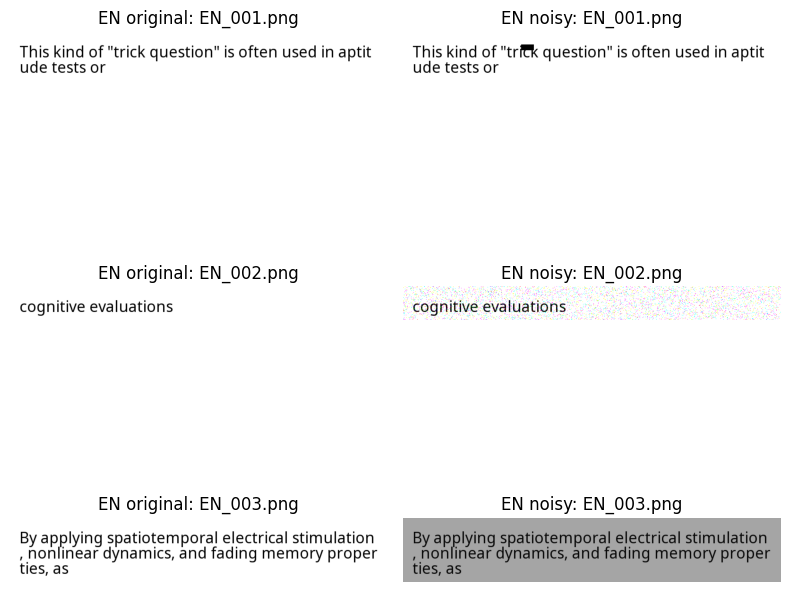

Showing samples for MY


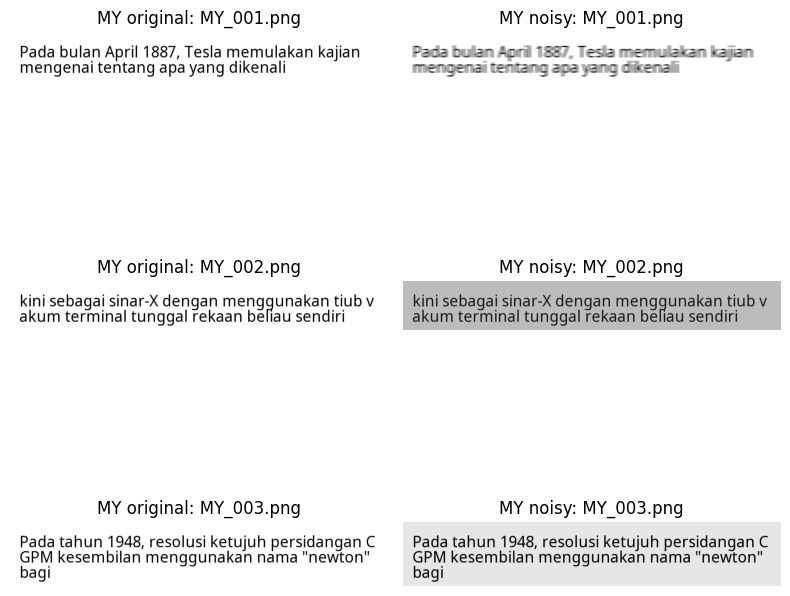

Showing samples for CN


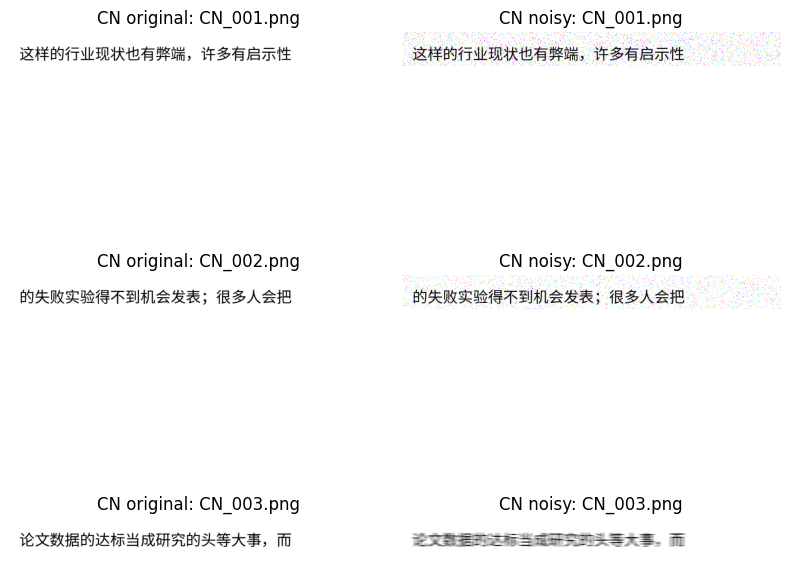

In [ ]:
# 6) Verify noise application (sample pairs)
import matplotlib.pyplot as plt

SAMPLES_PER_LANG = 3

for lang in LANGS:
    print(f'Showing samples for {lang}')
    samples = all_items[lang][:SAMPLES_PER_LANG]
    fig, axes = plt.subplots(len(samples), 2, figsize=(8, 3*len(samples)))
    for idx, (fname, _) in enumerate(samples):
        orig = Image.open(SRC_DIR / lang / fname).convert('RGB')
        noisy = Image.open(DEST_DIR / lang / fname).convert('RGB')
        axes[idx, 0].imshow(orig)
        axes[idx, 0].set_title(f'{lang} original: {fname}')
        axes[idx, 0].axis('off')
        axes[idx, 1].imshow(noisy)
        axes[idx, 1].set_title(f'{lang} noisy: {fname}')
        axes[idx, 1].axis('off')
    plt.tight_layout()
    plt.show()

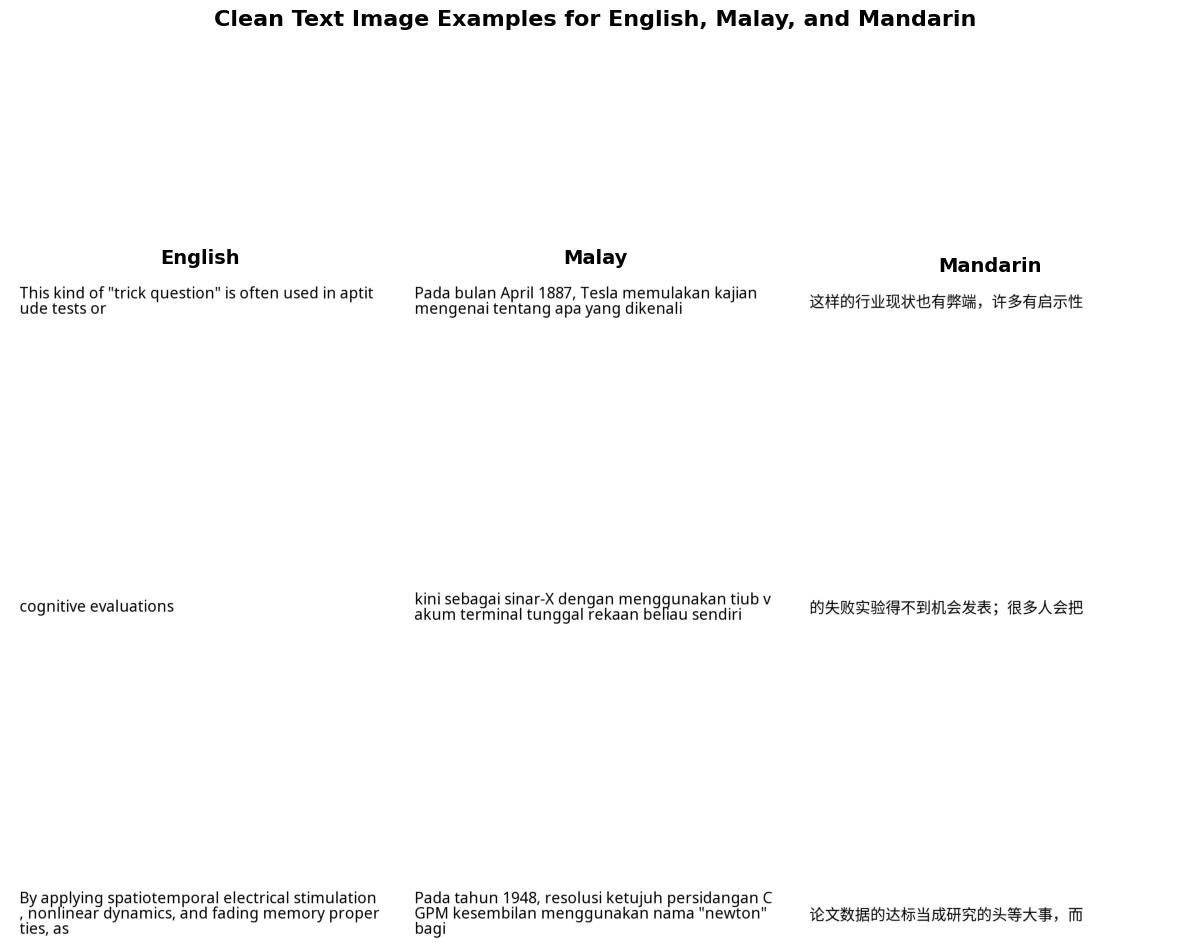

In [4]:
import csv
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

BASE_DIR = Path.cwd()
SRC_DIR = BASE_DIR / "ocr_images"
OUT_DIR = BASE_DIR / "figures"
OUT_DIR.mkdir(exist_ok=True)

SAMPLES = 3  # Change to 2 if you want only 2 rows

LANGS = ["EN", "MY", "CN"]
LANG_NAMES = ["English", "Malay", "Mandarin"]


def load_samples(lang, n):
    labels_path = SRC_DIR / lang / "labels.csv"
    samples = []

    with open(labels_path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            fname = row.get("filename") or row.get("file") or row.get("image")
            if fname:
                samples.append(fname)
            if len(samples) == n:
                break

    return samples


sample_dict = {
    lang: load_samples(lang, SAMPLES)
    for lang in LANGS
}

fig, axes = plt.subplots(
    SAMPLES,
    3,
    figsize=(12, 4 * SAMPLES)
)

# Column titles
for col in range(3):
    axes[0, col].set_title(
        LANG_NAMES[col],
        fontsize=14,
        fontweight="bold"
    )

for row in range(SAMPLES):
    for col, lang in enumerate(LANGS):

        fname = sample_dict[lang][row]
        img = Image.open(SRC_DIR / lang / fname).convert("RGB")

        axes[row, col].imshow(img)
        axes[row, col].axis("off")

plt.suptitle(
    "Clean Text Image Examples for English, Malay, and Mandarin",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()



plt.show()



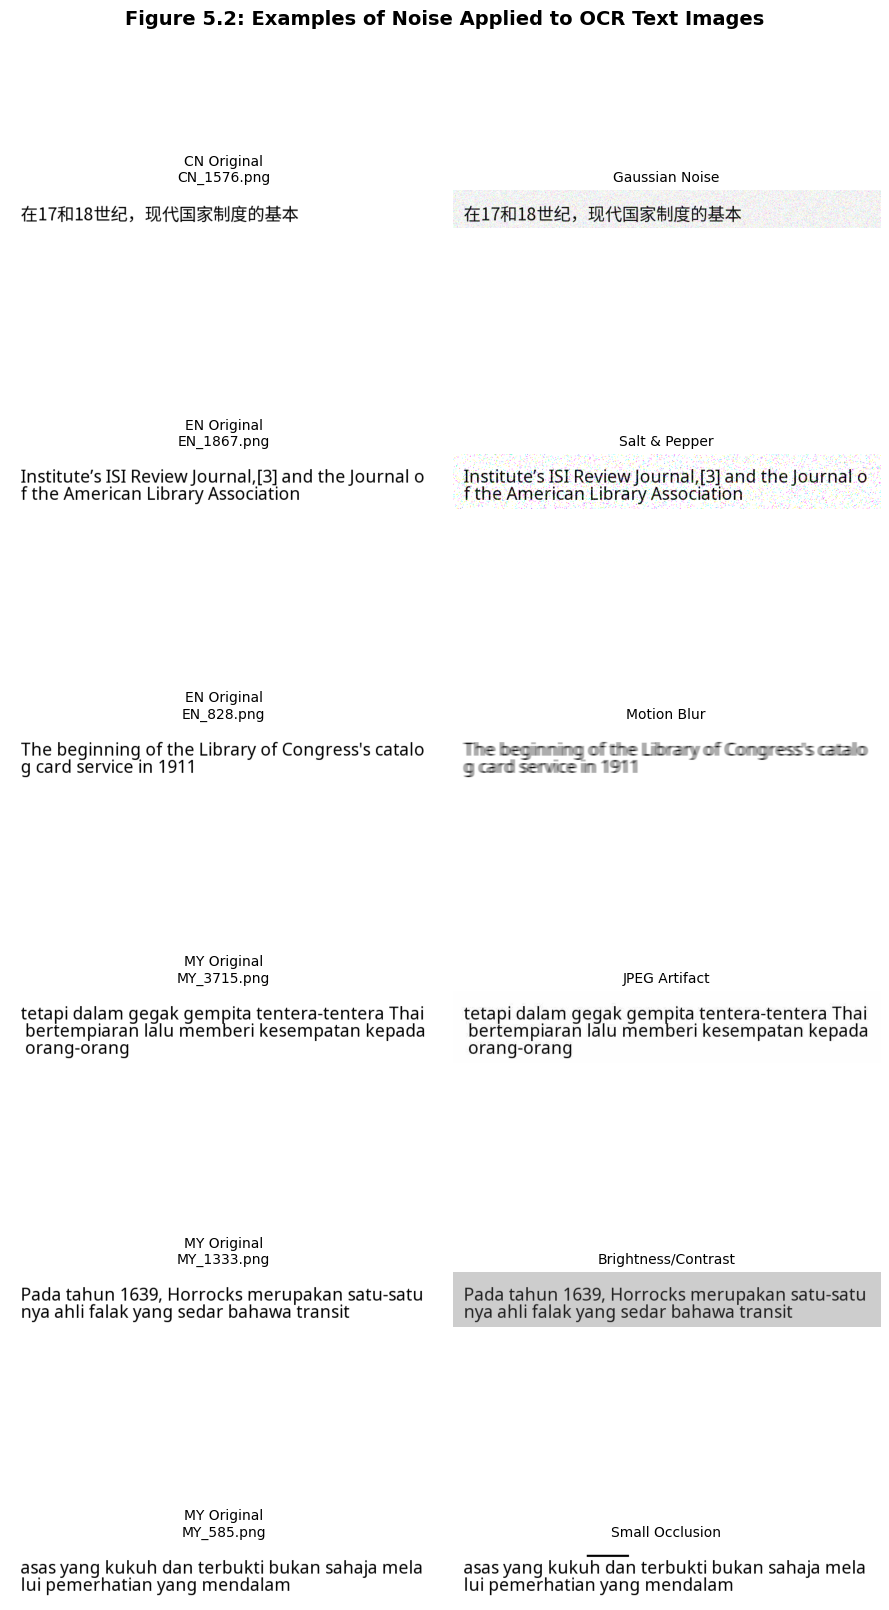

In [9]:
# 6) Show six random examples with unique noise types
import matplotlib.pyplot as plt
import random
from PIL import Image

OUT_DIR = BASE_DIR / "figures"
OUT_DIR.mkdir(exist_ok=True)

# Named noise functions for display
UNIQUE_NOISE_FUNCS = {
    "Gaussian Noise": lambda im: add_gaussian_noise(im, sigma=random.uniform(15, 40)),
    "Salt & Pepper": lambda im: add_salt_pepper(im, amount=random.uniform(0.02, 0.08), salt_vs_pepper=random.uniform(0.3, 0.7)),
    "Motion Blur": lambda im: add_motion_blur(im, ksize=random.choice([7, 9, 11])),
    "JPEG Artifact": lambda im: add_jpeg_artifact(im, quality=random.randint(8, 30)),
    "Brightness/Contrast": lambda im: add_brightness_contrast(im, brightness=random.uniform(0.6, 1.2), contrast=random.uniform(0.7, 1.3)),
    "Small Occlusion": lambda im: add_small_occlusion(im, max_frac=0.15),
}

# Pick one random image for each unique noise type
examples = []

for noise_name, noise_func in UNIQUE_NOISE_FUNCS.items():
    lang = random.choice(LANGS)
    fname, text = random.choice(all_items[lang])

    orig_path = SRC_DIR / lang / fname
    orig = Image.open(orig_path).convert("RGB")
    noisy = noise_func(orig)

    examples.append({
        "lang": lang,
        "fname": fname,
        "noise_name": noise_name,
        "orig": orig,
        "noisy": noisy
    })

# Plot 6 rows: original vs noisy
fig, axes = plt.subplots(
    len(examples),
    2,
    figsize=(9, 3 * len(examples))
)

for idx, ex in enumerate(examples):
    axes[idx, 0].imshow(ex["orig"])
    axes[idx, 0].set_title(
        f'{ex["lang"]} Original\n{ex["fname"]}',
        fontsize=10
    )
    axes[idx, 0].axis("off")

    axes[idx, 1].imshow(ex["noisy"])
    axes[idx, 1].set_title(
        f'{ex["noise_name"]}',
        fontsize=10
    )
    axes[idx, 1].axis("off")

plt.suptitle(
    "Figure 5.2: Examples of Noise Applied to OCR Text Images",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.show()
